In [1]:
import captum 
from captum.attr import IntegratedGradients, visualization as viz
import torch 
import dill
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sparse_generalization.models.mlp import BasicMLPLit
from sparse_generalization.data.shapes.constants import SHAPE_COLORS, SHAPES_TO_IDX, SHAPES, IDX_TO_SHAPES, SHAPE_MAP

/home/aryan/Documents/Uni/sparse-ood-generalization/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open('../data/shapes/shapes_test_a_size8.pl', 'rb') as file:
    test_data_A = dill.load(file)

with open('../data/shapes/shapes_test_b_size8.pl', 'rb') as file:
    test_data_B = dill.load(file)

with open('../data/shapes/shapes_train_size8.pl', 'rb') as file:
    train = dill.load(file)

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_shape(grid, attribution=None, cmap='hot'):
    size = grid.size(0)
    fig, ax = plt.subplots(figsize=(size + 1, size)) # Extra width for colorbar
    grid = grid.detach().cpu().numpy()
    
    if attribution is not None:
        attribution = attribution.cpu().detach().numpy()
        # Use a robust normalization for visualization
        attr_min, attr_max = attribution.min(), attribution.max()
        color_map = plt.get_cmap(cmap)

    for r in range(size):
        for c in range(size):
            x = c + 0.5
            y = size - r - 0.5
            
            if attribution is not None:
                norm_val = (attribution[r, c] - attr_min) / (attr_max - attr_min + 1e-9)
                rect_color = color_map(norm_val)
                rect = patches.Rectangle((c, size - r - 1), 1, 1, 
                                         linewidth=0, facecolor=rect_color, alpha=0.8)
                ax.add_patch(rect)

            shape_idx = grid[r, c].item()
            shape = IDX_TO_SHAPES[shape_idx]
            color = SHAPE_COLORS[shape]
            obj = SHAPE_MAP[shape](x, y, color=color)
            obj.draw(ax)

    if attribution is not None:
        sm = plt.cm.ScalarMappable(cmap=color_map, norm=plt.Normalize(vmin=attr_min, vmax=attr_max))
        cb = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        cb.set_label('Attribution Strength')

    ax.set_xlim(0, size)
    ax.set_ylim(0, size)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title("Model Focus (Attribution Heatmap)")

    return fig, ax

In [11]:
import torch
import torch.nn.functional as F
from captum.attr import IntegratedGradients, Saliency, GuidedBackprop
import matplotlib.pyplot as plt
import os

def run_attribution_analysis(checkpoint_path, data_dict, set_name, true_idx, false_idx, attr_method_class=IntegratedGradients, **kwargs):
    os.makedirs('../media/images', exist_ok=True)
    
    model = BasicMLPLit.load_from_checkpoint(checkpoint_path)
    model.eval()
    
    explainer = attr_method_class(model)

    def process_example(idx):
        prep = f'X_test_{set_name}' if len(set_name) > 0 else 'X_train'
        raw_x = data_dict[prep][idx]
        
        x_input = F.one_hot(raw_x.long().squeeze(), 64).unsqueeze(0).float()
        
        with torch.no_grad():
            logits = model(x_input)
            pred_val = torch.sigmoid(logits).item()
            
        x_input.requires_grad_()
        attr = explainer.attribute(x_input, **kwargs)
        spatial_attr = attr.abs().sum(dim=-1).squeeze(0)
        
        return raw_x, spatial_attr, pred_val

    indices = [true_idx, false_idx]
    labels = ["True", "False"]

    for idx, label_type in zip(indices, labels):
        x, attr, pred = process_example(idx)
        fig, ax = draw_shape(x, attr)
        
        method_name = attr_method_class.__name__
        set_label = set_name.capitalize() if set_name else ""
        title = f"{label_type} Example ({set_label}) - {method_name} - Pred ({pred:.4f})"
        ax.set_title(title)
        
        filename = f"../media/images/test{set_label}_{method_name}_{label_type}_{idx}.jpg"
        plt.savefig(filename, bbox_inches='tight')
        plt.show()
        plt.close(fig)

# Example Usage with Integrated Gradients
path = '../checkpoints/mlp_run_simple_10_Apr_2026__15h39m.ckpt'


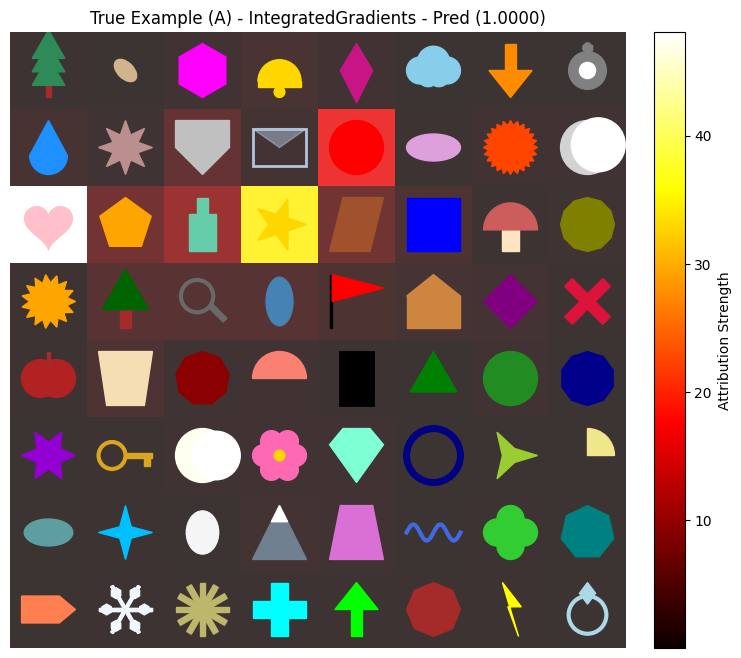

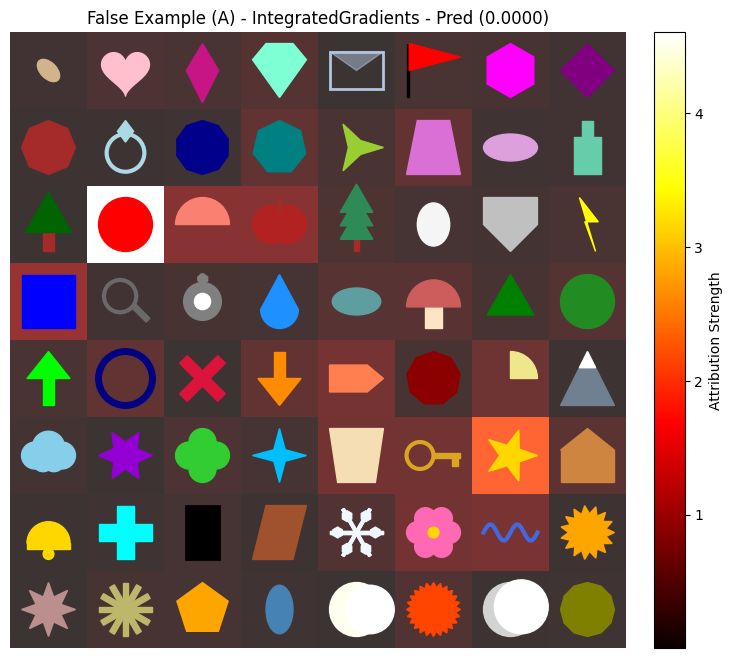

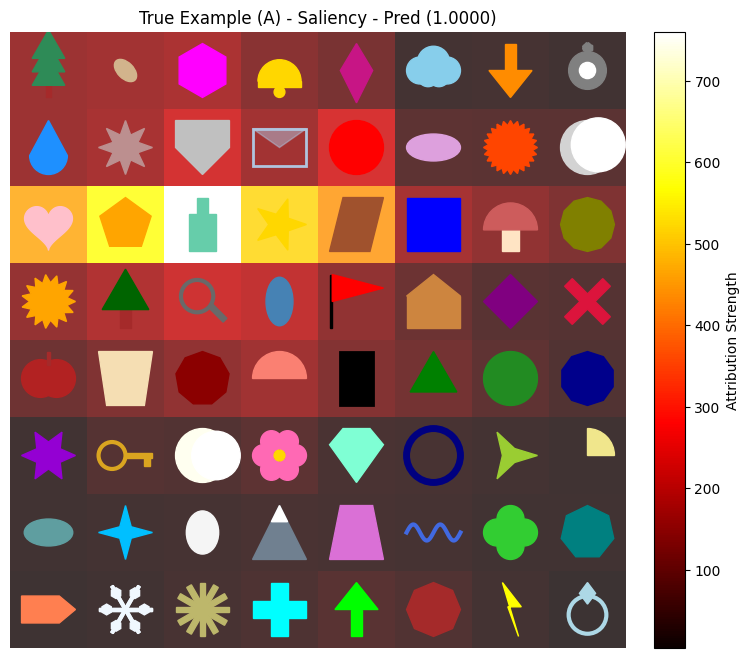

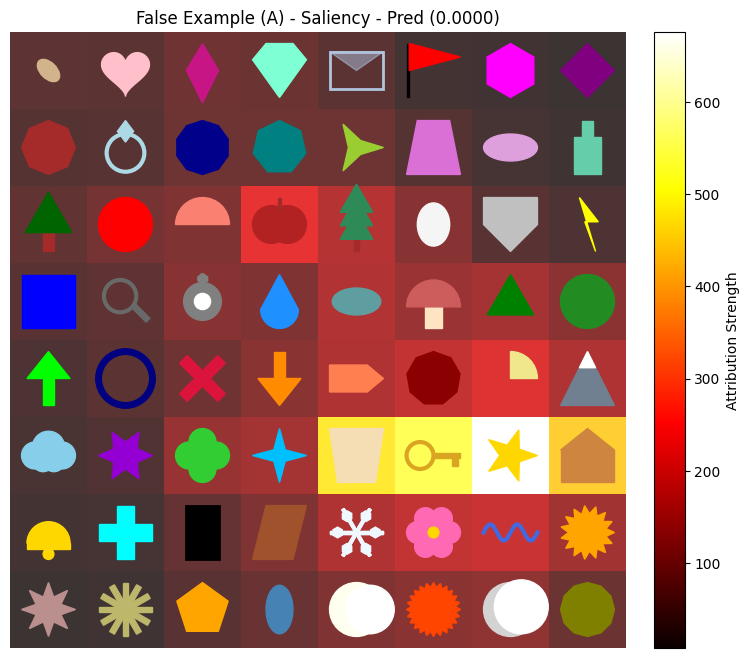

/home/aryan/Documents/Uni/sparse-ood-generalization/.venv/lib/python3.13/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:64: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


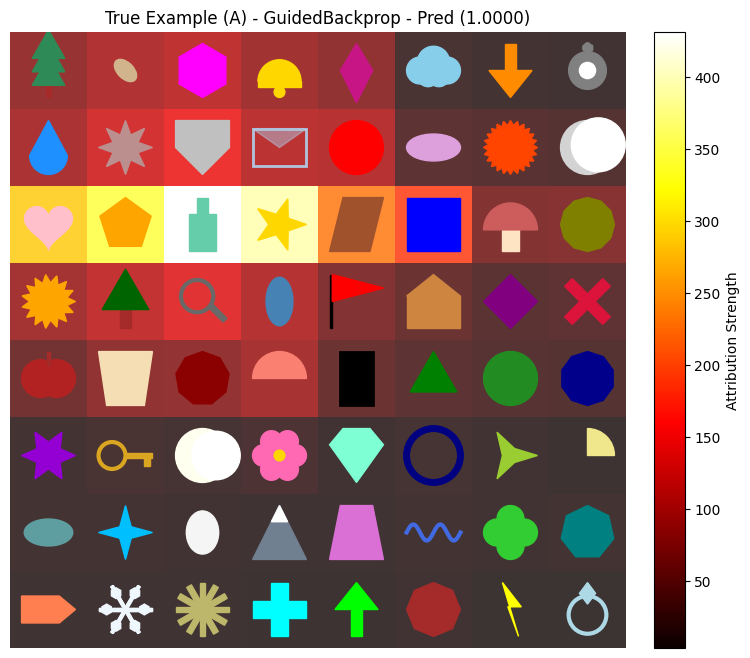

/home/aryan/Documents/Uni/sparse-ood-generalization/.venv/lib/python3.13/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:64: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


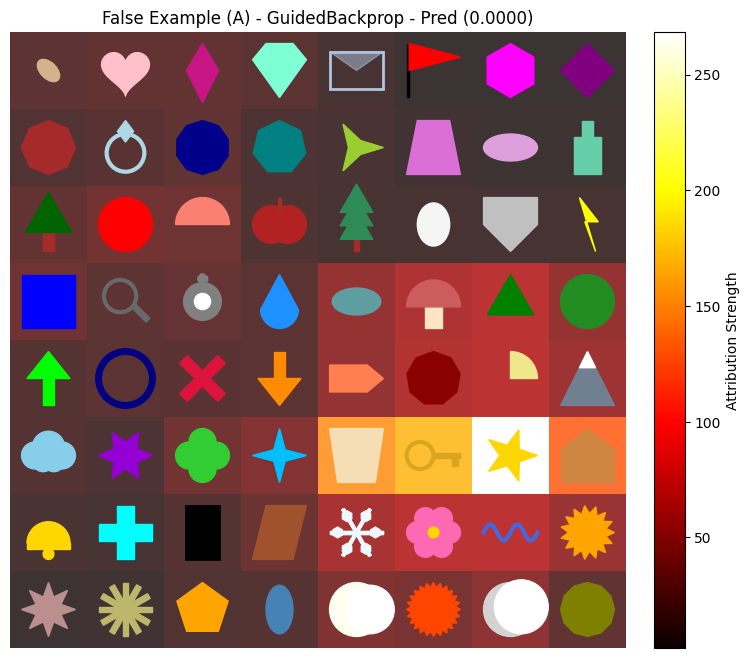

In [13]:
run_attribution_analysis(
    path, 
    test_data_A,
    'a',  
    100, 
    4000, 
    attr_method_class=IntegratedGradients, 
    target=None, 
    n_steps=20, 
    internal_batch_size=1
)

# Example Usage with Saliency (Faster/Lower Memory)
run_attribution_analysis(path, test_data_A, 'a', 100, 4000, attr_method_class=Saliency, target=None)
run_attribution_analysis(path, test_data_A, 'a', 100, 4000, attr_method_class=GuidedBackprop, target=None)

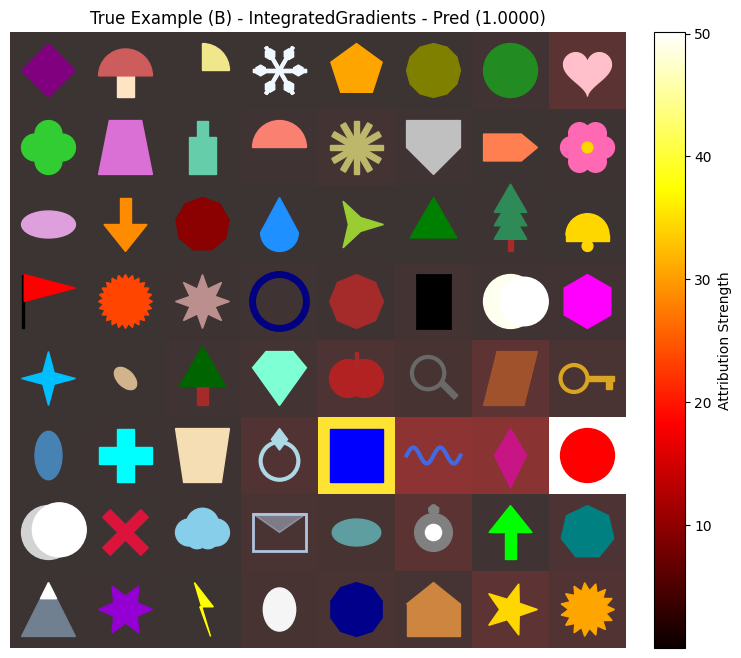

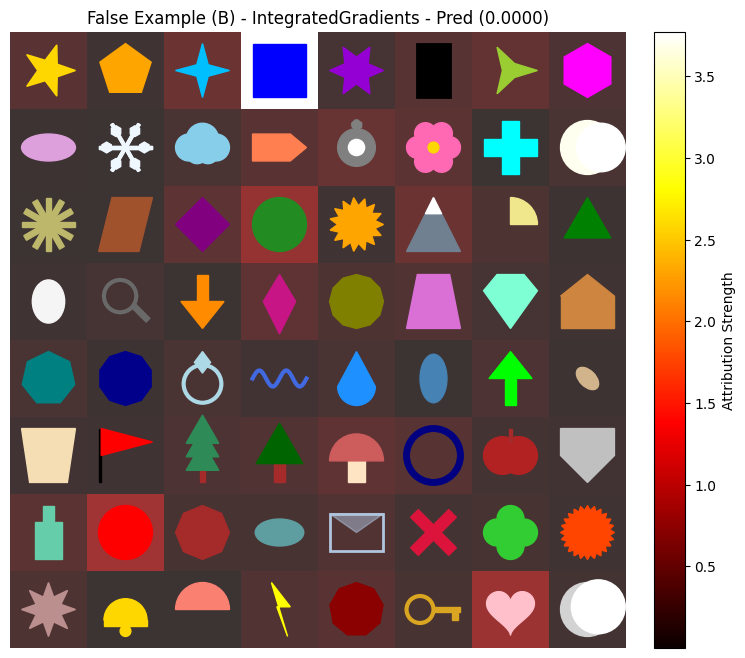

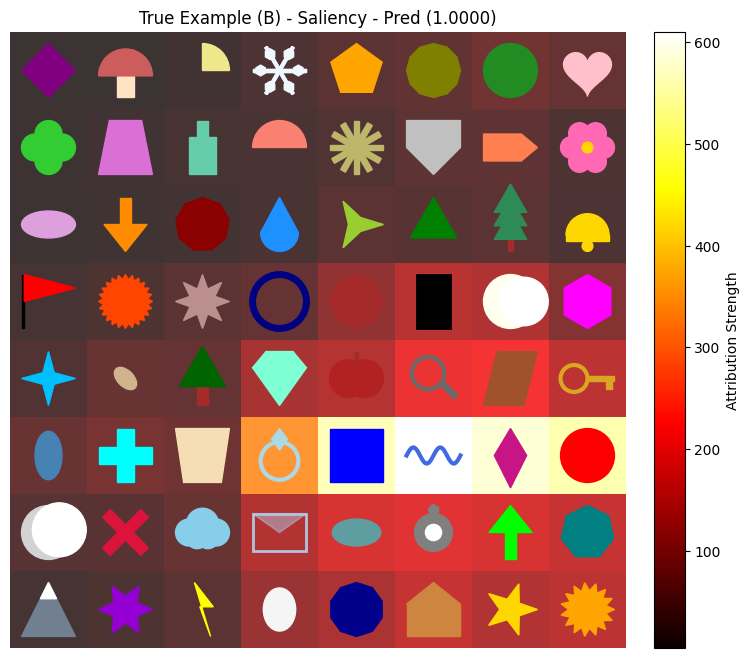

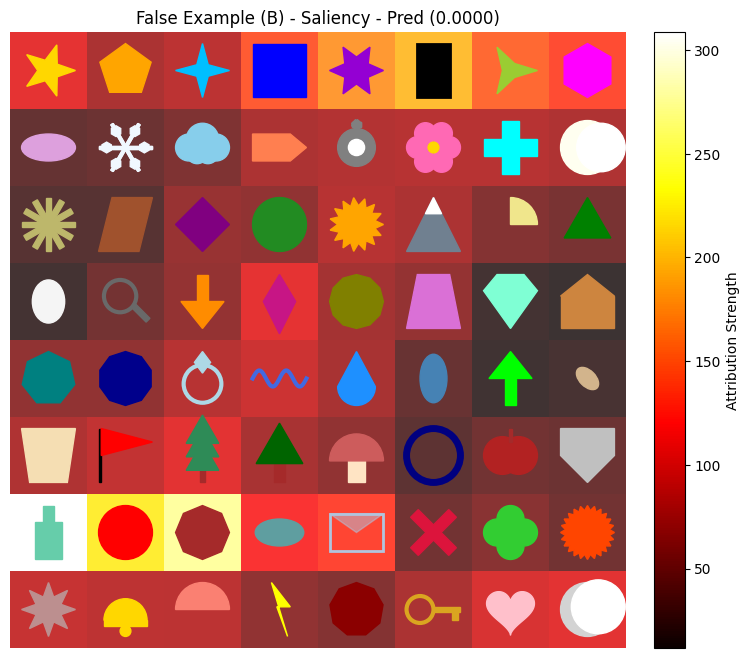

/home/aryan/Documents/Uni/sparse-ood-generalization/.venv/lib/python3.13/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:64: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


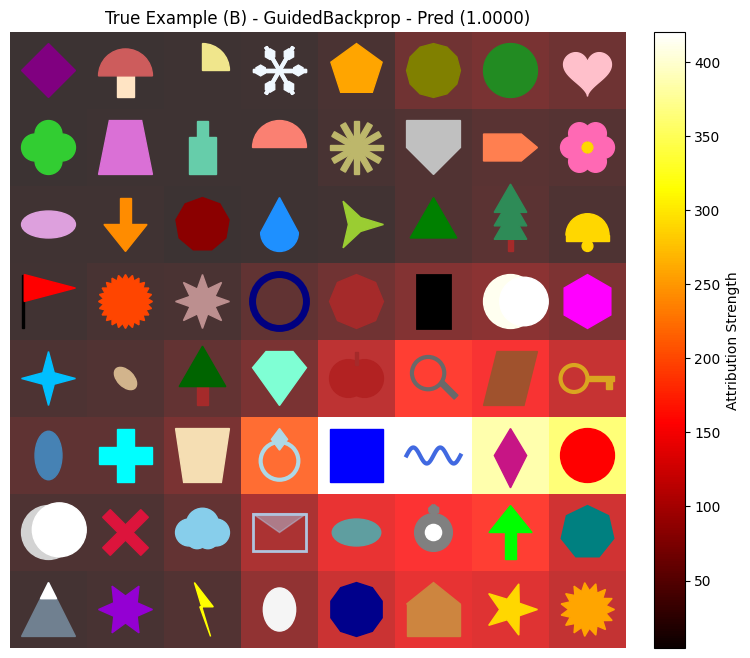

/home/aryan/Documents/Uni/sparse-ood-generalization/.venv/lib/python3.13/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:64: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


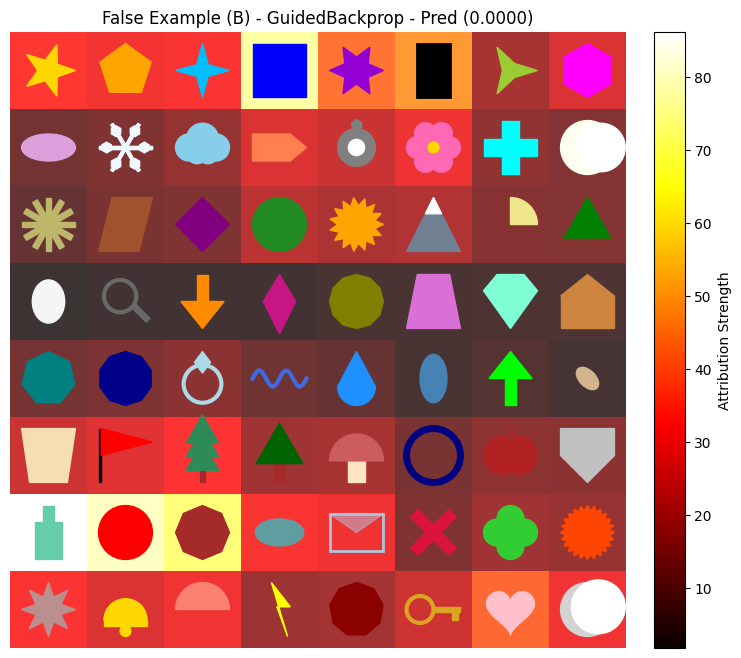

In [14]:
run_attribution_analysis(
    path, 
    test_data_B,
    'b',  
    100, 
    4000, 
    attr_method_class=IntegratedGradients, 
    target=None, 
    n_steps=20, 
    internal_batch_size=1
)

# Example Usage with Saliency (Faster/Lower Memory)
run_attribution_analysis(path, test_data_B, 'b', 100, 4000, attr_method_class=Saliency, target=None)
run_attribution_analysis(path, test_data_B, 'b', 100, 4000, attr_method_class=GuidedBackprop, target=None)

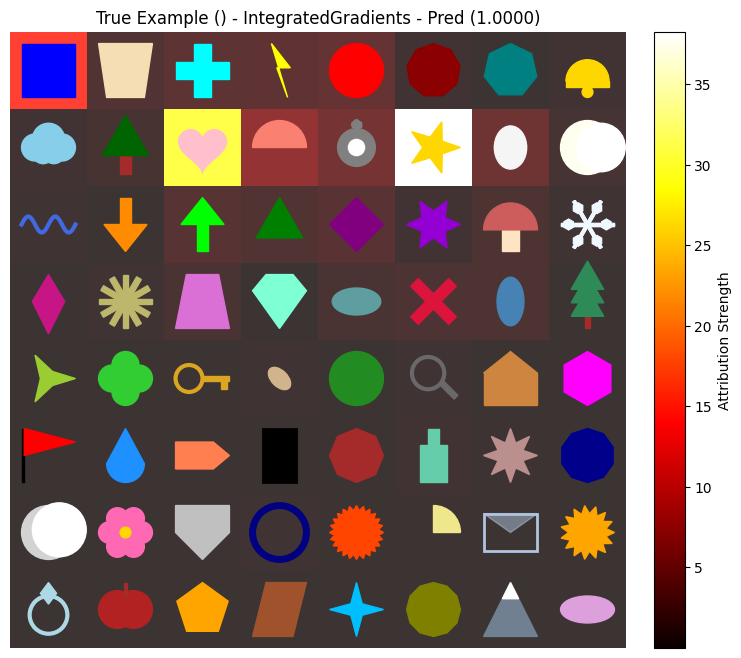

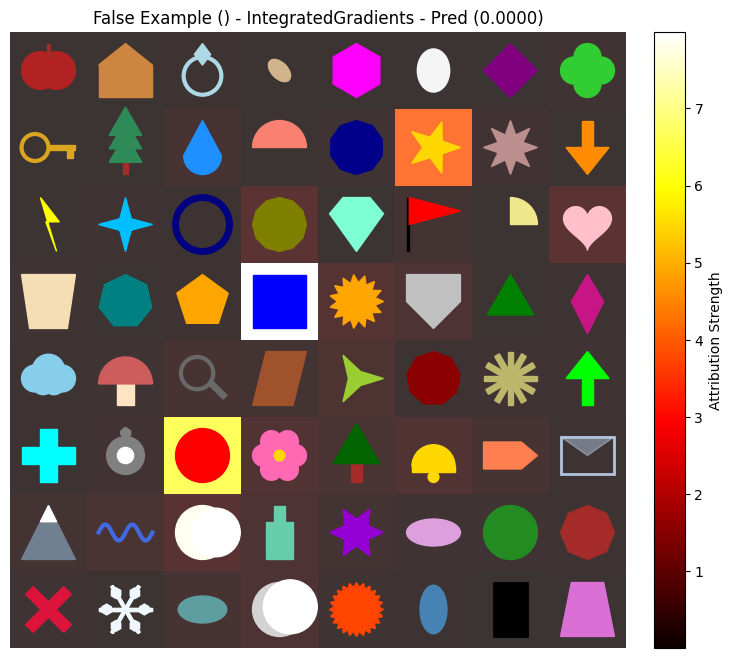

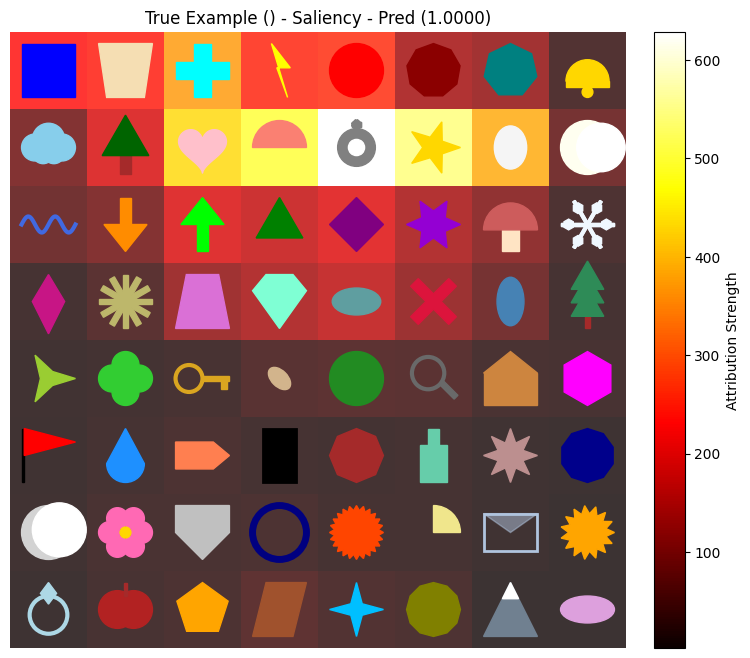

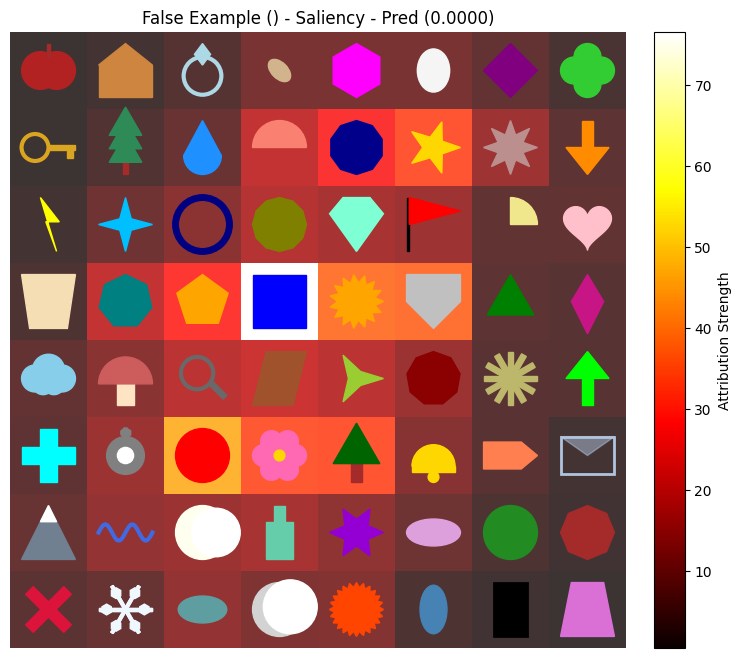

/home/aryan/Documents/Uni/sparse-ood-generalization/.venv/lib/python3.13/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:64: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


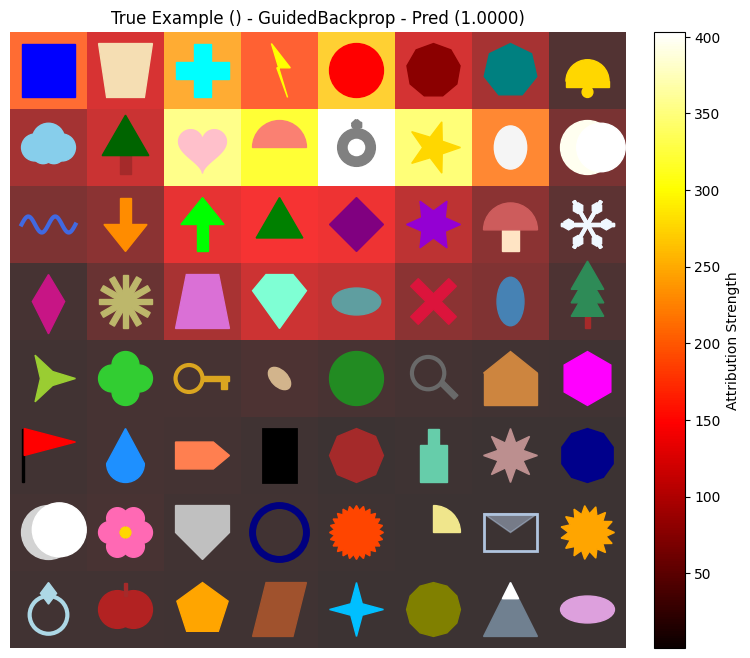

/home/aryan/Documents/Uni/sparse-ood-generalization/.venv/lib/python3.13/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:64: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


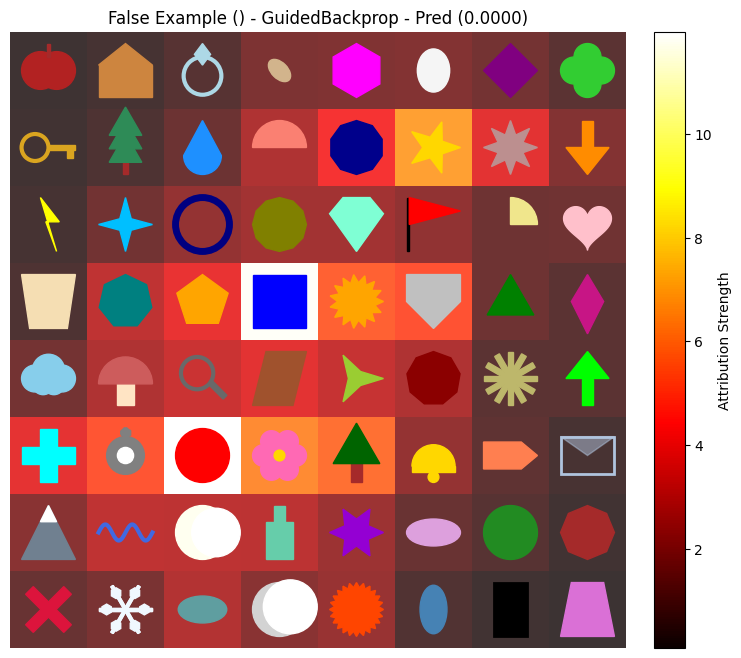

In [15]:
run_attribution_analysis(
    path, 
    train,
    '',  
    21000, 
    43000, 
    attr_method_class=IntegratedGradients, 
    target=None, 
    n_steps=20, 
    internal_batch_size=1
)

# Example Usage with Saliency (Faster/Lower Memory)
run_attribution_analysis(path, train, '', 21000, 43000, attr_method_class=Saliency, target=None)
run_attribution_analysis(path, train, '', 21000, 43000, attr_method_class=GuidedBackprop, target=None)